In [158]:
import numpy as np
from matplotlib import pyplot as plt
import tqdm

from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

from polychrom.hdf5_format import HDF5Reporter, list_URIs, load_URI, load_hdf5_file, save_hdf5_file
from polychrom.contactmaps import monomerResolutionContactMapSubchains


In [159]:
files = list_URIs('/mnt/md1/jjusuf/polysim/outputs/trajectory0001_npoly70000_nchr1_dens0.3_life75000_sep240_vlef0.0025_dt40_stallsites0.05-0.6_lifeboost4_ntypes2')
print(f'+LE +EP: {len(files)} blocks')


+LE +EP: 2100 blocks


In [160]:
region_size = 2000
chrom_size = 70000
num_regions = chrom_size // region_size
region_starts = np.arange(num_regions) * region_size

block_start = 0
block_end = 1300
block_step = 60


In [165]:
cutoff = 2
nproc = 4

cm = monomerResolutionContactMapSubchains(filenames=files[block_start:block_end:block_step], mapStarts=region_starts, mapN=region_size, cutoff=cutoff, n=nproc)


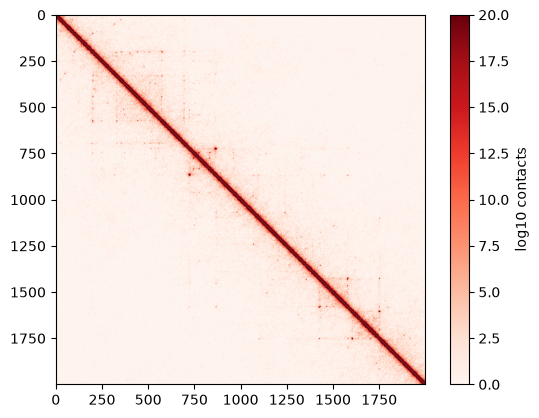

In [167]:
plt.imshow(cm, cmap='Reds', vmin=0, vmax=20);
plt.colorbar(label='log10 contacts');


# analyze CTCF loops

In [168]:
# Two LEFs are linked when any leg of one sits within `link_dist` monomers of any leg
# of the other -- exactly what the old in_contact() tested by intersecting the
# {pos-1, pos, pos+1} neighbourhood of every leg against every other. Two CTCF
# monomers are in contact when both are occupied by a leg and those two LEFs land in
# the same connected component of that relation.
#
# The old code rebuilt an N x N transitive closure for every (pair, region, block).
# Instead, label every LEF once per config: shift each block and each region into its
# own slice of a synthetic coordinate, separated by more than link_dist so nothing
# links across them, and the whole trajectory becomes one sort plus one
# connected_components call. On a line, linking only consecutive sorted legs already
# closes over every pair within link_dist, so no pairwise comparison is needed.

link_dist = 2                                        # max leg separation that links two LEFs
region_pad = region_size + 4 * link_dist
block_pad = num_regions * region_pad + 4 * link_dist


def label_lefs(lef_positions):
    """Connected-component label for every (block, LEF).

    Returns the labels plus the per-leg region / local-coordinate arrays, and the mask
    of LEFs that sit entirely inside one region (the others are dropped, matching the
    original per-region filter).
    """
    nblocks, nlefs, _ = lef_positions.shape

    region = lef_positions // region_size
    local = lef_positions - region * region_size
    inside = region[:, :, 0] == region[:, :, 1]      # drop LEFs straddling a boundary

    blocks = np.arange(nblocks)[:, None, None]
    coord = blocks * block_pad + region * region_pad + local
    node = np.arange(nblocks)[:, None] * nlefs + np.arange(nlefs)[None, :]

    keep = np.repeat(inside[:, :, None], 2, axis=2).ravel()
    coord = coord.ravel()[keep]
    owner = np.repeat(node[:, :, None], 2, axis=2).ravel()[keep]

    order = np.argsort(coord, kind='stable')
    coord, owner = coord[order], owner[order]
    linked = np.diff(coord) <= link_dist
    src, dst = owner[:-1][linked], owner[1:][linked]

    n_nodes = nblocks * nlefs
    graph = coo_matrix((np.ones(src.size, dtype=np.int8), (src, dst)),
                       shape=(n_nodes, n_nodes))
    _, labels = connected_components(graph, directed=False)
    return labels.reshape(nblocks, nlefs), inside, region, local


def site_labels(lef_positions):
    """Component label sitting on each CTCF monomer: (num_blocks, num_regions, n_sites).

    -1 means no LEF leg occupies that monomer in that block, so it cannot be looped.
    """
    nblocks = lef_positions.shape[0]
    labels, inside, region, local = label_lefs(lef_positions)

    column = site_index[local]                       # -1 for legs off a CTCF monomer
    sel = np.repeat(inside[:, :, None], 2, axis=2) & (column >= 0)

    at_site = np.full((nblocks, num_regions, len(ctcf_sites)), -1, dtype=labels.dtype)
    blocks = np.broadcast_to(np.arange(nblocks)[:, None, None], column.shape)
    per_leg = np.broadcast_to(labels[:, :, None], column.shape)
    at_site[blocks[sel], region[sel], column[sel]] = per_leg[sel]
    return at_site


def contact_matrix(at_site, col1, col2):
    """Boolean (num_blocks, num_repeats): is this CTCF pair looped in that block/region?"""
    a = at_site[:, :, col1]
    b = at_site[:, :, col2]
    return (a >= 0) & (a == b)

def loop_probability(contact):
    """Fraction of blocks in contact, averaged within each region then over regions."""
    return float(contact.mean(axis=0).mean())


def contact_durations(contact):
    """Lengths of the runs of consecutive in-contact blocks, with censoring flags.

    Walks the time axis of each region independently and returns one entry per
    contiguous stretch of contact. A run touching either end of the trajectory is
    censored: its recorded length is only a lower bound on the true loop lifetime,
    because the loop was already there when recording started, or still there when it
    stopped. Durations are in blocks; multiply by saveevery for LEF steps.
    """
    nblocks, nreg = contact.shape
    edge = np.zeros((1, nreg), dtype=bool)
    change = np.diff(np.vstack([edge, contact, edge]).astype(np.int8), axis=0)

    starts = np.argwhere(change == 1)                # (block, region) where a run opens
    ends = np.argwhere(change == -1)                 # (block, region) one past its close
    starts = starts[np.lexsort((starts[:, 0], starts[:, 1]))]
    ends = ends[np.lexsort((ends[:, 0], ends[:, 1]))]

    durations = ends[:, 0] - starts[:, 0]
    censored = (starts[:, 0] == 0) | (ends[:, 0] == nblocks)
    return durations, censored


def kaplan_meier(durations, censored):
    """Kaplan-Meier survival curve S(t) for the observed loop durations.

    S(t) = prod over event times t_j <= t of (1 - d_j / n_j), with n_j the number of
    loops still intact just before t_j and d_j the number that broke at t_j. Censored
    runs count towards n_j up to their own duration and then drop out, so they inform
    the curve without being treated as breakages.
    """
    durations = np.asarray(durations, dtype=float)
    if durations.size == 0:
        return np.empty(0), np.empty(0)

    observed = ~np.asarray(censored, dtype=bool)
    times = np.unique(durations)
    at_risk = durations.size - np.searchsorted(np.sort(durations), times, side='left')
    n_events = np.bincount(np.searchsorted(times, durations[observed]),
                           minlength=times.size)
    return times, np.cumprod(1.0 - n_events / at_risk)


def median_lifetime(durations, censored):
    """Median loop lifetime in blocks: the first time S(t) falls to 0.5 or below.

    NaN when the curve never gets there -- more than half the loops outlast the
    recording, so the median is not identified by this trajectory.
    """
    times, surv = kaplan_meier(durations, censored)
    reached = np.nonzero(surv <= 0.5)[0]
    return float(times[reached[0]]) if reached.size else np.nan


In [170]:
num_SMCs = load_URI(files[0])['SMCs'].shape[0]
lef_positions = np.zeros((len(files)//block_step, num_SMCs, 2), dtype='int')
block_step = 10
for i, block in enumerate(range(0, len(files), block_step)):
    lef_positions[i,:,:] = load_URI(files[block])['SMCs']
    

In [172]:
ctcf_left = [200, 330, 724, 1425, 1433, 1604]  # right-facing
ctcf_right = [574, 694, 866, 1241, 1390, 1580, 1752, 1800]  # left-facing
convergent_ctcf_pairs = []
for pos1 in ctcf_left:
    for pos2 in ctcf_right:
        if pos1 < pos2:
            convergent_ctcf_pairs.append((pos1, pos2))
print(f'Identified {len(convergent_ctcf_pairs)} convergent CTCF pairs per region')

# Only the CTCF monomers are ever queried, so carry labels for those columns alone
# instead of for all region_size monomers.
ctcf_sites = sorted(set(ctcf_left) | set(ctcf_right))
site_index = np.full(region_size, -1, dtype=np.int64)   # monomer -> column, -1 = not a site
site_index[ctcf_sites] = np.arange(len(ctcf_sites))
pair_columns = [(ctcf_sites.index(pos1), ctcf_sites.index(pos2))
                for pos1, pos2 in convergent_ctcf_pairs]

at_site = site_labels(lef_positions)

rows = []
for (pos1, pos2), (col1, col2) in zip(convergent_ctcf_pairs, pair_columns):
    contact = contact_matrix(at_site, col1, col2)
    durations, censored = contact_durations(contact)
    median = median_lifetime(durations, censored)
    print({'pos1': pos1, 'pos2': pos2,
        'loop_prob': loop_probability(contact),
        'median_lifetime_saveblocks': median,
        'n_loops': int(durations.size),
        'n_censored': int(censored.sum()),
    })


Identified 30 convergent CTCF pairs per region
{'pos1': 200, 'pos2': 574, 'loop_prob': 0.09224489795918367, 'median_lifetime_saveblocks': 18.0, 'n_loops': 9, 'n_censored': 3}
{'pos1': 200, 'pos2': 694, 'loop_prob': 0.02435374149659864, 'median_lifetime_saveblocks': 22.0, 'n_loops': 10, 'n_censored': 5}
{'pos1': 200, 'pos2': 866, 'loop_prob': 0.007755102040816326, 'median_lifetime_saveblocks': 57.0, 'n_loops': 1, 'n_censored': 0}
{'pos1': 200, 'pos2': 1241, 'loop_prob': 0.0, 'median_lifetime_saveblocks': nan, 'n_loops': 0, 'n_censored': 0}
{'pos1': 200, 'pos2': 1390, 'loop_prob': 0.0, 'median_lifetime_saveblocks': nan, 'n_loops': 0, 'n_censored': 0}
{'pos1': 200, 'pos2': 1580, 'loop_prob': 0.0, 'median_lifetime_saveblocks': nan, 'n_loops': 0, 'n_censored': 0}
{'pos1': 200, 'pos2': 1752, 'loop_prob': 0.0032653061224489793, 'median_lifetime_saveblocks': 24.0, 'n_loops': 1, 'n_censored': 0}
{'pos1': 200, 'pos2': 1800, 'loop_prob': 0.0, 'median_lifetime_saveblocks': nan, 'n_loops': 0, 'n_ce

In [152]:
sticky_elements = np.array([250, 372, 540, 745, 775, 833, 961, 1202, 1330, 1640, 1722])

def calculate_contact_freq(files, pos1, pos2, block_start, block_end, block_step, cutoff):
    blocks_to_sample = np.arange(block_start, block_end, block_step)
    mean_contacts = np.zeros(len(blocks_to_sample))
    for i, block_num in enumerate(blocks_to_sample):
        monomer_positions = load_URI(files[block_num])['pos']
        displacement_vectors = monomer_positions[region_starts+pos1]-monomer_positions[region_starts+pos2]
        distances = np.linalg.norm(displacement_vectors, axis=1)
        mean_contacts[i] = np.mean(distances < cutoff)
    return np.mean(mean_contacts)


In [157]:
for i in sticky_elements:
    for j in sticky_elements:
        if i < j:
            prob = calculate_contact_freq(files, i, j, 0, len(files), 100, 2)
            if prob > 0.005:
                print(f'{i:<4} {j:<4} {prob*100:.2f}%')


250  372  4.18%
250  540  0.66%
250  745  1.32%
250  775  1.32%
250  833  0.66%
250  1640 0.66%
372  540  3.52%
372  745  0.88%
372  775  0.66%
372  961  0.66%
372  1330 0.66%
540  745  2.20%
540  775  2.20%
540  833  1.76%
540  961  0.66%
540  1202 0.66%
745  775  13.41%
745  833  4.84%
745  961  3.52%
745  1202 0.66%
745  1330 0.66%
745  1640 1.76%
775  833  6.81%
775  961  2.64%
775  1330 1.98%
775  1640 0.88%
833  961  2.20%
833  1202 1.32%
833  1330 0.88%
961  1330 0.88%
1202 1330 2.20%
1202 1640 1.10%
1202 1722 1.54%
1330 1640 0.88%
1330 1722 1.10%
1640 1722 5.27%
